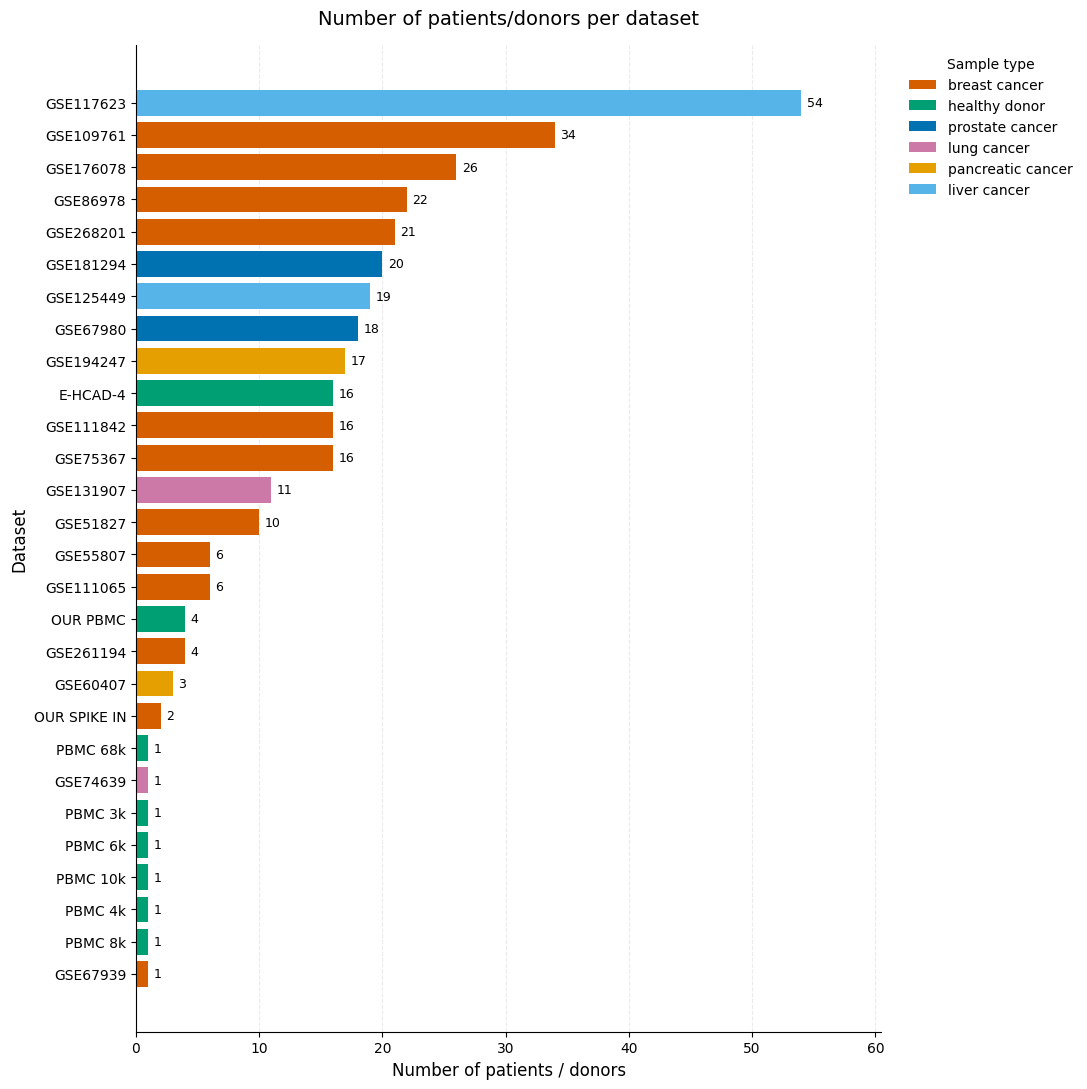

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# =========================
# 1. Wczytanie danych
# =========================

df = pd.read_excel(
    "datasets(2).ods",
    engine="odf"
)

df = df[["GEO GSE", "Sample type", "Patient number"]].copy()

df["Patient number"] = pd.to_numeric(
    df["Patient number"],
    errors="coerce"
)

df = df.dropna(
    subset=["GEO GSE", "Sample type", "Patient number"]
)


# =========================
# 2. Kolejność grup
# =========================

sample_type_order = [
    "breast cancer",
    "prostate cancer",
    "lung cancer",
    "pancreatic cancer",
    "liver cancer",
    "healthy donor"
]

df["Sample type"] = pd.Categorical(
    df["Sample type"],
    categories=sample_type_order,
    ordered=True
)

# grupowanie po Sample type,
# a następnie sortowanie po liczbie pacjentów
df = df.sort_values(
    ["Sample type", "Patient number"],
    ascending=[True, False]
).reset_index(drop=True)


# =========================
# 3. Kolory
# =========================

color_map = {
    "breast cancer": "#D55E00",
    "prostate cancer": "#0072B2",
    "lung cancer": "#CC79A7",
    "pancreatic cancer": "#E69F00",
    "liver cancer": "#56B4E9",
    "healthy donor": "#009E73"
}


# =========================
# 4. Pozycje słupków
#    + przerwy między grupami
# =========================

y_positions = []
group_centers = {}
group_boundaries = []

current_y = 0
gap = 1.2

for sample_type in sample_type_order:

    group = df[df["Sample type"] == sample_type]

    if len(group) == 0:
        continue

    start_y = current_y

    for _ in range(len(group)):
        y_positions.append(current_y)
        current_y += 1

    end_y = current_y - 1

    # środek grupy
    group_centers[sample_type] = (start_y + end_y) / 2

    # miejsce na linię oddzielającą grupy
    group_boundaries.append(current_y - 0.5 + gap / 2)

    current_y += gap


df["y_position"] = y_positions


# =========================
# 5. Wykres
# =========================

fig, ax = plt.subplots(figsize=(12, 12))

colors = [
    color_map[str(sample_type)]
    for sample_type in df["Sample type"]
]

bars = ax.barh(
    df["y_position"],
    df["Patient number"],
    color=colors,
    height=0.75
)


# =========================
# 6. Nazwy datasetów
# =========================

ax.set_yticks(df["y_position"])
ax.set_yticklabels(
    df["GEO GSE"],
    fontsize=9
)

# pierwsza grupa na górze
ax.invert_yaxis()


# =========================
# 7. Liczby na słupkach
# =========================

for bar, value in zip(bars, df["Patient number"]):

    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(value)}",
        va="center",
        fontsize=9
    )


# =========================
# 8. Linie między grupami
# =========================

for boundary in group_boundaries[:-1]:

    ax.axhline(
        boundary,
        linewidth=0.8,
        alpha=0.25
    )


# =========================
# 9. Legenda
# =========================

legend_elements = [
    Patch(
        facecolor=color_map[sample_type],
        label=sample_type
    )
    for sample_type in sample_type_order
]

ax.legend(
    handles=legend_elements,
    title="Sample type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)


# =========================
# 10. Wygląd wykresu
# =========================

ax.set_xlabel(
    "Number of patients / donors",
    fontsize=12
)

ax.set_ylabel(
    "Dataset",
    fontsize=12
)

ax.set_title(
    "Number of patients/donors across datasets",
    fontsize=14,
    pad=15
)

ax.set_xlim(
    0,
    df["Patient number"].max() * 1.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.2
)

ax.set_axisbelow(True)

plt.tight_layout()


# =========================
# 11. Zapis
# =========================

plt.savefig(
    "datasets_grouped_by_sample_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()